# Modelagem de Score de Crédito com XGBoost e Random Forest

## Objetivo
Construir modelos de XGBoost e Random Forest de **classificação multiclasse** capazes de prever a faixa de score de crédito de um cliente (`Good`, `Standard` ou `Poor`) a partir de seu perfil financeiro e de seu histórico de pagamentos e comparar seu desempenho. Ambos os modelos utilizam a métrica de scoring F1 macro, que dá o mesmo peso a cada classe e evita que o modelo seja favorecido apenas por acertar a classe mais frequente.

## 1. Importação das bibliotecas
Bibliotecas usadas no projeto: manipulação de dados (`pandas`, `numpy`), modelagem (`xgboost`), métricas e validação (`scikit-learn`), visualização (`matplotlib`, `seaborn`) e serialização do modelo (`joblib`).

In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier

## 2. Carregamento dos dados
Leitura da base de treino já tratada (`clean_train.csv`), resultado do pipeline de limpeza e *feature engineering* feito anteriormente.

In [3]:
df = pd.read_csv('../data/clean_train.csv')

## 3. Visão geral da base
O `df.info()` confirma a estrutura do conjunto de dados:
- **87.535 registros** e **21 colunas**;
- variáveis categóricas já convertidas para formato numérico, prontas para o modelo;
- *features* derivadas de razões financeiras, como `Debt_to_Income`, `EMI_to_Salary` e `Balance_to_Salary`, além de interações como `Interest_x_Delay`;
- poucos valores nulos, restritos a `Num_Bank_Accounts`, `Delay_from_due_date` e `Interest_x_Delay`. Não precisam de imputação, pois o XGBoost trata ausências de forma nativa.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87535 entries, 0 to 87534
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               87535 non-null  str    
 1   Total_EMI_per_month       87535 non-null  float64
 2   Monthly_Inhand_Salary     87535 non-null  float64
 3   Monthly_Balance           87535 non-null  float64
 4   Credit_Mix                87535 non-null  float64
 5   Payment_of_Min_Amount     87535 non-null  float64
 6   Payment_Behaviour         87535 non-null  float64
 7   Num_Bank_Accounts         87515 non-null  float64
 8   Num_Credit_Card           87535 non-null  int64  
 9   Interest_Rate             87535 non-null  int64  
 10  Delay_from_due_date       87029 non-null  float64
 11  Num_Credit_Inquiries      87535 non-null  float64
 12  Outstanding_Debt          87535 non-null  float64
 13  Credit_History_Age_Years  87535 non-null  float64
 14  Credit_Score     

## 4. Preparação e divisão dos dados
- A coluna `Customer_ID` é usada como identificador no GroupKFold dos dados. Assim garantimos que nao haja clientes repetidos em dados de treino e teste e exploramos a eficacia real de predicao do modelo.
- `Credit_Score` é separada como variável-alvo (`y`); as demais colunas formam as variáveis preditoras (`X`).

In [5]:
ids = df.pop('Customer_ID')
X, y = df.drop("Credit_Score", axis=1), df["Credit_Score"]

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=4)
train_idx, test_idx = next(splitter.split(X, y, groups=ids))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

groups_train = ids.iloc[train_idx]

## 5. Definição do modelo e da busca de hiperparâmetros
Aqui são definidos os modelos base e o espaço de busca.

**Estratégia de busca:** `RandomizedSearchCV` testa combinações sorteadas do espaço acima, o que é bem mais barato do que uma busca exaustiva (*grid search*). Cada combinação é avaliada com **validação cruzada estratificada de 5 partições**, mantendo a proporção das classes em cada uma, e pontuada por **F1 macro**.

### 5.1 **Modelo base:** `XGBClassifier` com `tree_method='hist'` (mais rápido em bases grandes) e `mlogloss` como função de perda, adequada a problemas multiclasse.

**Hiperparâmetros explorados:**
| Hiperparâmetro     | O que controla                                                           |
| --------------------| --------------------------------------------------------------------------|
| `n_estimators`     | número de árvores no ensemble                                            |
| `max_depth`        | profundidade máxima de cada árvore                                       |
| `learning_rate`    | peso de cada árvore na atualização do modelo                             |
| `colsample_bytree` | fração de variáveis sorteadas por árvore                                 |
| `min_child_weight` | tamanho mínimo exigido em cada folha, o que ajuda a evitar *overfitting* |
| `subsample`        | fração de linhas sorteadas por árvore                                    |

In [6]:
PARAM_GRID_XG = {
    'n_estimators': [500, 700],
    'max_depth': [6, 9],
    'learning_rate': [0.05],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [5, 10],
    'subsample': [0.7, 0.9],
}

xgboost = xgb.XGBClassifier(
        random_state=4,
        num_class=3,
        objective='multi:softprob',
        eval_metric='mlogloss'
    )

random_search_xgb = RandomizedSearchCV(
    estimator=xgboost,
    param_distributions=PARAM_GRID_XG,
    scoring='f1_macro',
    verbose=0,
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=4),
    random_state=4,
    n_jobs=-1
)

### 5.2 **Modelo base:** `RandomForestClassifier` com `class_weight='balanced'` para classes desbalanceadas

**Hiperparâmetros explorados:**
| Hiperparâmetro | O que controla                     |
| ----------------| ------------------------------------|
| `n_estimators` | número de árvores no ensemble      |
| `max_depth`    | profundidade máxima de cada árvore |

In [7]:
PARAM_GRID_RF = {
    'n_estimators': [300, 500, 700],
    'max_depth': [6, 9],
}

rf = RandomForestClassifier(
    random_state=4,
    class_weight="balanced"
)

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=PARAM_GRID_RF,
    scoring='f1_macro',
    verbose=0,
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=4),
    n_jobs=-1
)

## 6. Treinamento
Execução da busca: para cada combinação sorteada, o modelo é treinado e validado nas 5 partições do conjunto de treino. Ao final, o `RandomizedSearchCV` reajusta o melhor modelo em todo o conjunto de treino e o disponibiliza para predição.

In [8]:
random_search_xgb.fit(X_train, y_train, groups=groups_train,verbose=False)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05], 'max_depth': [6, 9], 'min_child_weight': [5, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",4
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` inst

In [10]:
random_search_rf.fit(X_train, y_train, groups=groups_train)

/home/matheus/Dev/projeto_fraude/.venv/lib/python3.14/site-packages/sklearn/model_selection/_search.py:327: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=4)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [6, 9], 'n_estimators': [300, 500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.

# 7. Comparação dos modelos

Avaliamos os modelos com as métricas de acurácia, F1 macro, F1 weighted e F1 com validação cruzada. Para entender cada uma, considere que, para cada classe (`Good`, `Poor` e `Standard`), as predições do modelo se dividem em acertos e erros:

- **Precisão:** das previsões feitas para uma classe, qual fração estava correta. Responde à pergunta "quando o modelo diz que o cliente é `Good`, com que frequência ele acerta?".
- **Recall (revocação):** dos clientes que realmente pertencem a uma classe, qual fração o modelo conseguiu identificar. Responde à pergunta "de todos os clientes `Good`, quantos o modelo encontrou?".
- **F1:** média harmônica entre precisão e recall, calculada como `2 × (precisão × recall) / (precisão + recall)`. Por ser uma média harmônica, só é alta quando precisão e recall são altos ao mesmo tempo; se um dos dois for baixo, o F1 cai bastante. Varia de 0 a 1, e quanto mais próximo de 1, melhor.

Como o problema tem três classes, o F1 é calculado separadamente para cada uma e depois agregado de formas diferentes:

- **Acurácia:** proporção de previsões corretas em relação ao total de clientes do conjunto de teste. É simples de interpretar, mas pode enganar quando as classes são desbalanceadas, pois um modelo que acerta bem apenas a classe mais frequente já obtém um valor alto.
- **F1 macro:** média simples dos F1 de cada classe, dando o mesmo peso a todas, independentemente de quantos clientes cada uma tenha. Penaliza o modelo que vai mal em uma classe minoritária, por isso é a métrica usada para escolher os hiperparâmetros.
- **F1 weighted:** média dos F1 de cada classe ponderada pelo número de clientes de cada uma (o suporte). Reflete melhor o desempenho geral na distribuição real dos dados, mas as classes mais frequentes pesam mais no resultado.
- **F1 com validação cruzada:** F1 macro médio obtido nas 5 partições do conjunto de treino para a melhor combinação de hiperparâmetros (`best_score_`). Como cada partição é avaliada com dados que o modelo não viu no treinamento, estima a capacidade de generalização sem usar o conjunto de teste. Se for muito maior que o F1 macro do teste, pode indicar *overfitting* ou diferença entre os conjuntos.

Além dessas métricas, o `classification_report` mostra precisão, recall e F1 de cada classe, e a matriz de confusão mostra, em cada linha, a classe real e, em cada coluna, a classe prevista. Os valores na diagonal são os acertos, e os demais indicam quais classes o modelo costuma confundir entre si.

### 7.1. XGBoost

Acurácia:    0.6842
F1 macro:    0.6556
F1 weighted: 0.6838
F1 (validação cruzada): 0.6559
AUC macro:    0.8417
AUC weighted: 0.8230
Gini macro:   0.6834
Gini weighted:0.6461
              precision    recall  f1-score   support

        Good       0.57      0.58      0.58      3084
        Poor       0.68      0.64      0.66      4981
    Standard       0.72      0.74      0.73      9442

    accuracy                           0.68     17507
   macro avg       0.66      0.65      0.66     17507
weighted avg       0.68      0.68      0.68     17507



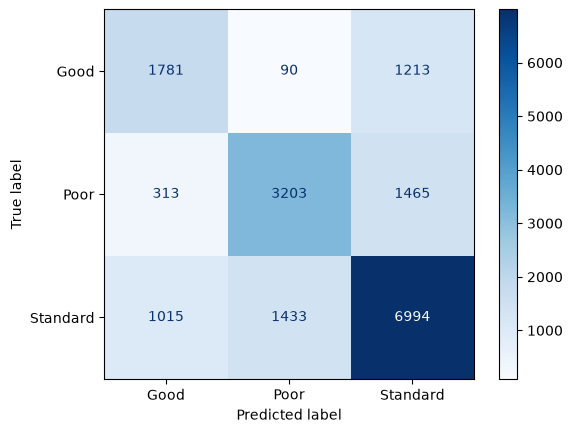

In [19]:
y_pred = random_search_xgb.predict(X_test)
y_proba = random_search_xgb.predict_proba(X_test)

auc_macro = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr',
    average='macro'
)

auc_weighted = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr',
    average='weighted'
)

gini_macro = 2 * auc_macro - 1
gini_weighted = 2 * auc_weighted - 1

print(f"Acurácia:    {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 macro:    {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 (validação cruzada): {random_search_xgb.best_score_:.4f}")
print(f"AUC macro:    {auc_macro:.4f}")
print(f"AUC weighted: {auc_weighted:.4f}")
print(f"Gini macro:   {gini_macro:.4f}")
print(f"Gini weighted:{gini_weighted:.4f}")

print(classification_report(y_test, y_pred, target_names=['Good', 'Poor', 'Standard']))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Good', 'Poor', 'Standard'], cmap='Blues'
)

### 7.2. Random Forest

Acurácia:    0.6750
F1 macro:    0.6678
F1 weighted: 0.6790
F1 (validação cruzada): 0.6559
AUC macro:    0.8416
AUC weighted: 0.8242
Gini macro:   0.6832
Gini weighted:0.6483
              precision    recall  f1-score   support

        Good       0.49      0.81      0.61      3084
        Poor       0.64      0.78      0.70      4981
    Standard       0.85      0.58      0.69      9442

    accuracy                           0.68     17507
   macro avg       0.66      0.72      0.67     17507
weighted avg       0.73      0.68      0.68     17507



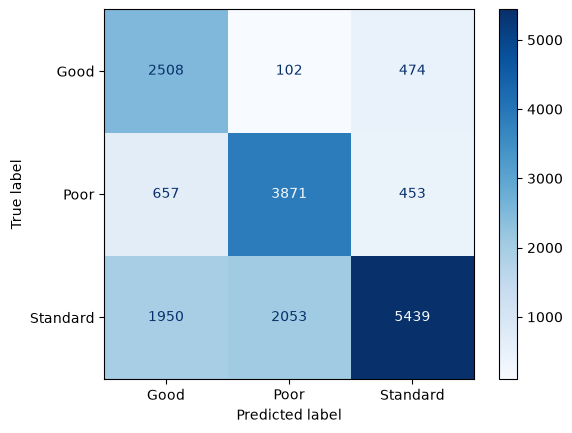

In [20]:
y_pred = random_search_rf.predict(X_test)
y_proba = random_search_rf.predict_proba(X_test)

auc_macro = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr',
    average='macro'
)

auc_weighted = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr',
    average='weighted'
)

gini_macro = 2 * auc_macro - 1
gini_weighted = 2 * auc_weighted - 1

print(f"Acurácia:    {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 macro:    {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 (validação cruzada): {random_search_xgb.best_score_:.4f}")
print(f"AUC macro:    {auc_macro:.4f}")
print(f"AUC weighted: {auc_weighted:.4f}")
print(f"Gini macro:   {gini_macro:.4f}")
print(f"Gini weighted:{gini_weighted:.4f}")

print(classification_report(y_test, y_pred, target_names=['Good', 'Poor', 'Standard']))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Good', 'Poor', 'Standard'], cmap='Blues'
)

# 8. Exportação do modelo

Exportamos o modelo com as melhores métricas de desempenho.

In [11]:
path = '../models/credit_model.joblib'
joblib.dump(random_search_xgb.best_estimator_, path)

['../models/credit_model.joblib']